# Tarea: Aplicación del Algoritmo Mapper

Autor: Thanos Drossos

**Objetivo:** Aplicar el algoritmo Mapper para analizar los siguientes conjuntos de datos:

1. **B³** - Bola métrica en tres dimensiones
2. **S²** - Corteza de una bola métrica (superficie de la esfera)
3. **Círculo unitario** - Disco completo en 2D
4. **S¹** - Perímetro del círculo unitario

En todos los casos utilizaremos N = 500 puntos y aplicaremos diferentes estrategias de análisis topológico usando TDA Mapper.

---

## Parte 1: Bola Métrica en Tres Dimensiones (B³)

Generamos 500 puntos uniformemente distribuidos dentro de una bola de radio 1 en R³.

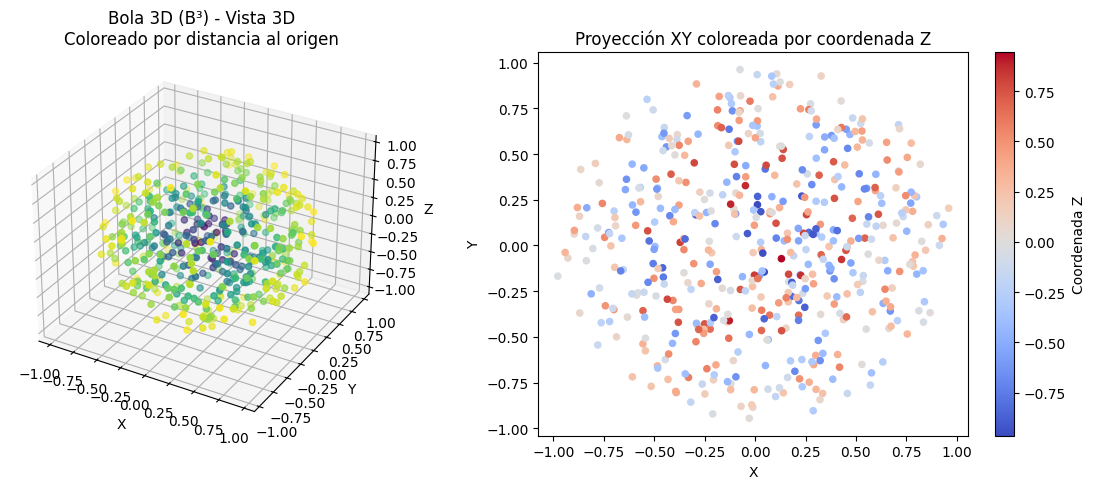

Datos generados: 500 puntos en R³
Rango de distancias al origen: [0.155, 0.999]


In [89]:
# Parte 1: Bola métrica en tres dimensiones (B³)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from tdamapper.learn import MapperAlgorithm
from tdamapper.cover import CubicalCover
from tdamapper.plot import MapperPlot

def generate_ball_3d(n_samples=500, radius=1.0, random_state=42):
    """Genera puntos uniformemente distribuidos en una bola 3D"""
    np.random.seed(random_state)
    
    # Método de rechazo: generar puntos en cubo y rechazar los que están fuera
    points = []
    while len(points) < n_samples:
        # Generar punto aleatorio en cubo [-radius, radius]³
        x = np.random.uniform(-radius, radius, 3)
        # Verificar si está dentro de la bola
        if np.linalg.norm(x) <= radius:
            points.append(x)
    
    return np.array(points)

# Generar datos B³
X_ball3d = generate_ball_3d(n_samples=500, random_state=42)

# Visualizar los datos
fig = plt.figure(figsize=(12, 5))

# Vista 3D
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_ball3d[:, 0], X_ball3d[:, 1], X_ball3d[:, 2], 
           c=np.linalg.norm(X_ball3d, axis=1), cmap='viridis', s=20)
ax1.set_title('Bola 3D (B³) - Vista 3D\nColoreado por distancia al origen')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Proyección 2D (primeras dos coordenadas)
ax2 = fig.add_subplot(122)
scatter = ax2.scatter(X_ball3d[:, 0], X_ball3d[:, 1], 
                     c=X_ball3d[:, 2], cmap='coolwarm', s=20)
ax2.set_title('Proyección XY coloreada por coordenada Z')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
plt.colorbar(scatter, ax=ax2, label='Coordenada Z')

plt.tight_layout()
plt.show()

print(f"Datos generados: {X_ball3d.shape[0]} puntos en R³")
print(f"Rango de distancias al origen: [{np.min(np.linalg.norm(X_ball3d, axis=1)):.3f}, {np.max(np.linalg.norm(X_ball3d, axis=1)):.3f}]")

In [90]:
# Aplicar Mapper a la bola 3D
# Usar PCA como función lente para reducir de 3D a 2D
pca_ball3d = PCA(n_components=2, random_state=42)
y_ball3d = pca_ball3d.fit_transform(X_ball3d)

# Configurar Mapper
cover_ball3d = CubicalCover(n_intervals=12, overlap_frac=0.4)
clust_ball3d = DBSCAN(eps=0.15, min_samples=3)
mapper_ball3d = MapperAlgorithm(cover_ball3d, clust_ball3d)

# Construir grafo Mapper
graph_ball3d = mapper_ball3d.fit_transform(X_ball3d, y_ball3d)

# Crear colores basados en la distancia al origen
distances_ball3d = np.linalg.norm(X_ball3d, axis=1)

# Visualizar el grafo Mapper
fig_ball3d = MapperPlot(graph_ball3d, dim=2, seed=42, iterations=80).plot_plotly(  
    colors=distances_ball3d
)
fig_ball3d.update_layout(title="Mapper Graph - Bola 3D (B³) - Coloreado por distancia al origen")
fig_ball3d.show(config={"scrollZoom": True})

print(f"Grafo Mapper B³: {graph_ball3d.number_of_nodes()} nodos, {graph_ball3d.number_of_edges()} aristas")
print(f"Varianza explicada por PCA: {pca_ball3d.explained_variance_ratio_}")

Grafo Mapper B³: 99 nodos, 61 aristas
Varianza explicada por PCA: [0.35119568 0.32688661]


## Parte 2: S² - Corteza de una Bola Métrica (Superficie de la Esfera)

Generamos 500 puntos uniformemente distribuidos en la superficie de una esfera de radio 1.

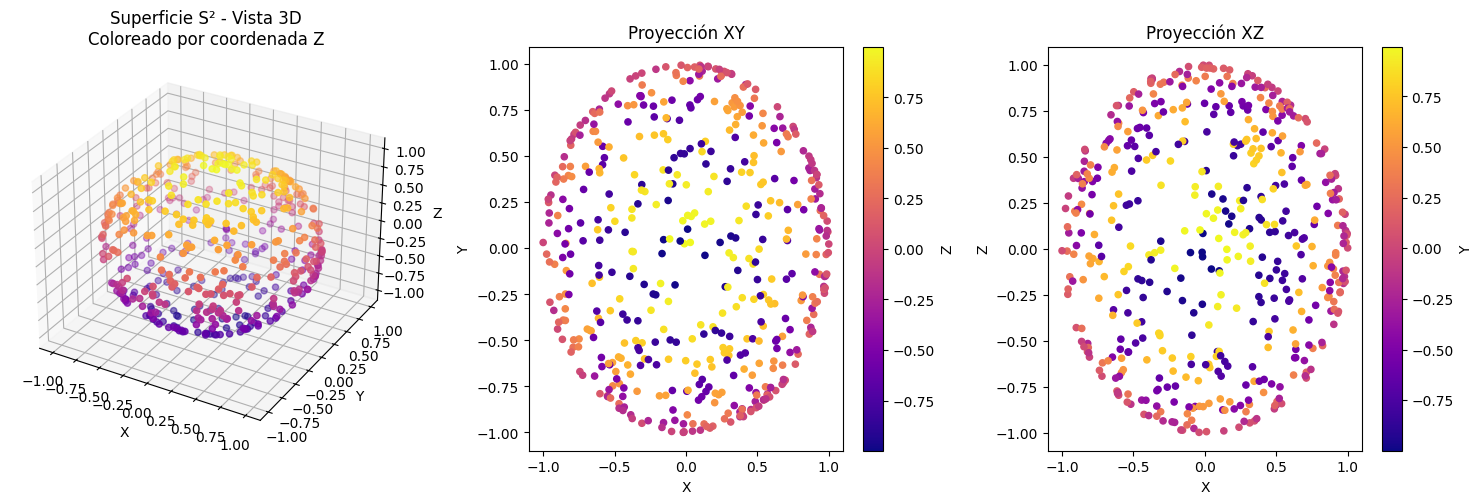

Datos S²: 500 puntos
Radio promedio: 1.000000 (debe ser ≈1.0)
Desviación estándar del radio: 0.00000000


In [91]:
# Parte 2: S² - Superficie de la esfera
def generate_sphere_surface(n_samples=500, radius=1.0, random_state=42):
    """Genera puntos uniformemente distribuidos en la superficie de una esfera"""
    np.random.seed(random_state)
    
    # Método de Marsaglia: generar puntos gaussianos y normalizar
    points = np.random.randn(n_samples, 3)
    # Normalizar para que estén en la superficie de la esfera
    norms = np.linalg.norm(points, axis=1, keepdims=True)
    points = radius * points / norms
    
    return points

# Generar datos S²
X_sphere = generate_sphere_surface(n_samples=500, random_state=42)

# Visualizar los datos
fig = plt.figure(figsize=(15, 5))

# Vista 3D
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_sphere[:, 0], X_sphere[:, 1], X_sphere[:, 2], 
           c=X_sphere[:, 2], cmap='plasma', s=20)
ax1.set_title('Superficie S² - Vista 3D\nColoreado por coordenada Z')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Proyección XY
ax2 = fig.add_subplot(132)
scatter1 = ax2.scatter(X_sphere[:, 0], X_sphere[:, 1], 
                      c=X_sphere[:, 2], cmap='plasma', s=20)
ax2.set_title('Proyección XY')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
plt.colorbar(scatter1, ax=ax2, label='Z')

# Proyección XZ
ax3 = fig.add_subplot(133)
scatter2 = ax3.scatter(X_sphere[:, 0], X_sphere[:, 2], 
                      c=X_sphere[:, 1], cmap='plasma', s=20)
ax3.set_title('Proyección XZ')
ax3.set_xlabel('X')
ax3.set_ylabel('Z')
plt.colorbar(scatter2, ax=ax3, label='Y')

plt.tight_layout()
plt.show()

# Verificar que todos los puntos están en la superficie
radii = np.linalg.norm(X_sphere, axis=1)
print(f"Datos S²: {X_sphere.shape[0]} puntos")
print(f"Radio promedio: {np.mean(radii):.6f} (debe ser ≈1.0)")
print(f"Desviación estándar del radio: {np.std(radii):.8f}")

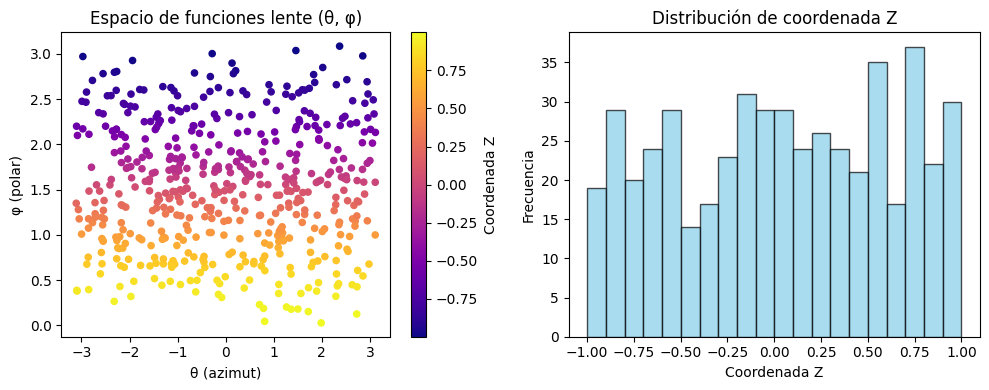

Grafo Mapper S²: 126 nodos, 137 aristas
Rango θ: [-3.109, 3.114]
Rango φ: [0.027, 3.085]


In [92]:
# Aplicar Mapper a S²
# Para S², usaremos coordenadas esféricas (θ, φ) como función lente
def cartesian_to_spherical(points):
    """Convierte coordenadas cartesianas a esféricas (θ, φ)"""
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    
    # θ (azimut): ángulo en el plano XY desde el eje X
    theta = np.arctan2(y, x)
    
    # φ (polar): ángulo desde el eje Z positivo
    phi = np.arccos(z)  # z = r*cos(φ), y r=1
    
    return np.column_stack([theta, phi])

# Convertir a coordenadas esféricas
y_sphere = cartesian_to_spherical(X_sphere)

# Configurar Mapper para S²
cover_sphere = CubicalCover(n_intervals=15, overlap_frac=0.3)
clust_sphere = DBSCAN(eps=0.2, min_samples=3)
mapper_sphere = MapperAlgorithm(cover_sphere, clust_sphere)

# Construir grafo Mapper
graph_sphere = mapper_sphere.fit_transform(X_sphere, y_sphere)

# Crear colores basados en la coordenada Z
z_coords = X_sphere[:, 2]

# Visualizar el grafo Mapper
fig_sphere = MapperPlot(graph_sphere, dim=2, seed=42, iterations=100).plot_plotly(
    colors=z_coords
)
fig_sphere.update_layout(title="Mapper Graph - Superficie S² - Coloreado por coordenada Z")
fig_sphere.show(config={"scrollZoom": True})

# Mostrar información del espacio de funciones lente
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_sphere[:, 0], y_sphere[:, 1], c=z_coords, cmap='plasma', s=20)
plt.xlabel('θ (azimut)')
plt.ylabel('φ (polar)')
plt.title('Espacio de funciones lente (θ, φ)')
plt.colorbar(label='Coordenada Z')

plt.subplot(1, 2, 2)
plt.hist(z_coords, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Coordenada Z')
plt.ylabel('Frecuencia')
plt.title('Distribución de coordenada Z')

plt.tight_layout()
plt.show()

print(f"Grafo Mapper S²: {graph_sphere.number_of_nodes()} nodos, {graph_sphere.number_of_edges()} aristas")
print(f"Rango θ: [{np.min(y_sphere[:, 0]):.3f}, {np.max(y_sphere[:, 0]):.3f}]")
print(f"Rango φ: [{np.min(y_sphere[:, 1]):.3f}, {np.max(y_sphere[:, 1]):.3f}]")

## Parte 3: Círculo Unitario (Disco Completo)

Generamos 500 puntos uniformemente distribuidos dentro de un círculo de radio 1 en R².

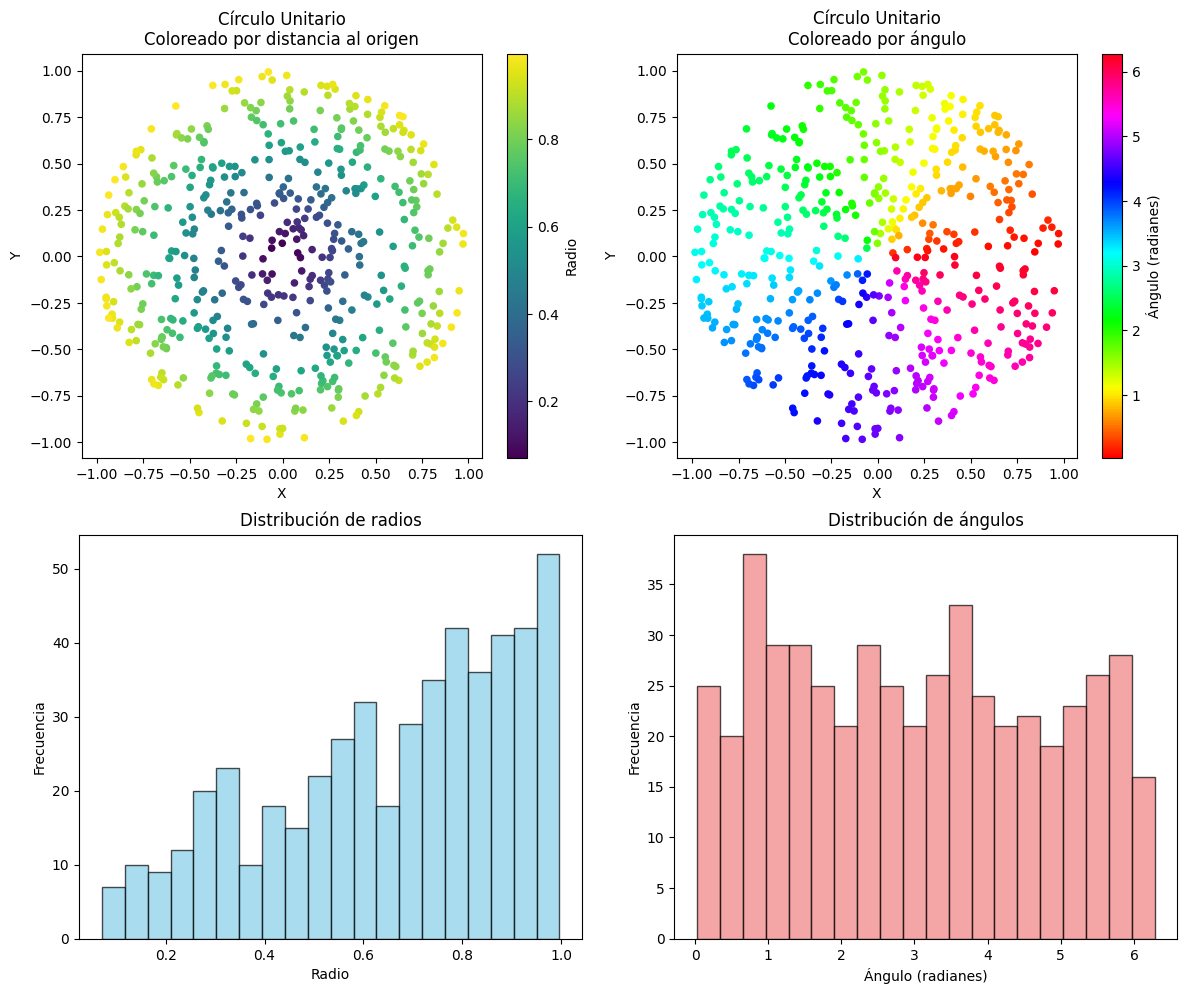

Datos del disco: 500 puntos en R²
Rango de radios: [0.071, 0.996]
Radio promedio: 0.662


In [93]:
# Parte 3: Círculo unitario (disco completo)
def generate_unit_disk(n_samples=500, radius=1.0, random_state=42):
    """Genera puntos uniformemente distribuidos en un disco"""
    np.random.seed(random_state)
    
    # Método polar: generar radio y ángulo
    # Para distribución uniforme en área, r ~ sqrt(U) donde U ~ Uniform(0,1)
    r = radius * np.sqrt(np.random.uniform(0, 1, n_samples))
    theta = np.random.uniform(0, 2*np.pi, n_samples)
    
    # Convertir a coordenadas cartesianas
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    return np.column_stack([x, y]), r, theta

# Generar datos del círculo unitario
X_disk, radii_disk, theta_disk = generate_unit_disk(n_samples=500, random_state=42)

# Visualizar los datos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Disco coloreado por radio
im1 = axes[0,0].scatter(X_disk[:, 0], X_disk[:, 1], c=radii_disk, cmap='viridis', s=20)
axes[0,0].set_title('Círculo Unitario\nColoreado por distancia al origen')
axes[0,0].set_xlabel('X')
axes[0,0].set_ylabel('Y')
axes[0,0].set_aspect('equal')
plt.colorbar(im1, ax=axes[0,0], label='Radio')

# Disco coloreado por ángulo
im2 = axes[0,1].scatter(X_disk[:, 0], X_disk[:, 1], c=theta_disk, cmap='hsv', s=20)
axes[0,1].set_title('Círculo Unitario\nColoreado por ángulo')
axes[0,1].set_xlabel('X')
axes[0,1].set_ylabel('Y')
axes[0,1].set_aspect('equal')
plt.colorbar(im2, ax=axes[0,1], label='Ángulo (radianes)')

# Histograma de radios
axes[1,0].hist(radii_disk, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Radio')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].set_title('Distribución de radios')

# Histograma de ángulos
axes[1,1].hist(theta_disk, bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('Ángulo (radianes)')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].set_title('Distribución de ángulos')

plt.tight_layout()
plt.show()

print(f"Datos del disco: {X_disk.shape[0]} puntos en R²")
print(f"Rango de radios: [{np.min(radii_disk):.3f}, {np.max(radii_disk):.3f}]")
print(f"Radio promedio: {np.mean(radii_disk):.3f}")

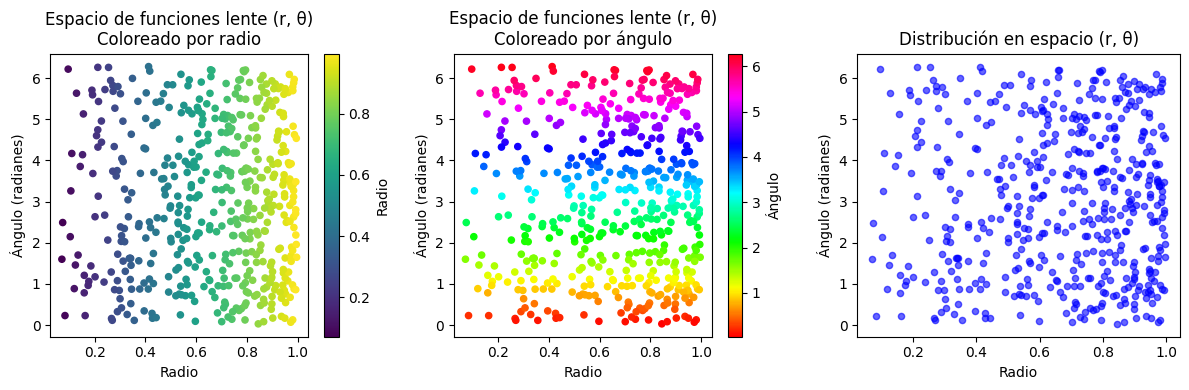

Grafo Mapper Círculo: 121 nodos, 236 aristas


In [94]:
# Aplicar Mapper al círculo unitario
# Usaremos coordenadas polares (r, θ) como función lente
y_disk = np.column_stack([radii_disk, theta_disk])

# Configurar Mapper para el disco
cover_disk = CubicalCover(n_intervals=10, overlap_frac=0.4)
clust_disk = DBSCAN(eps=0.12, min_samples=3)
mapper_disk = MapperAlgorithm(cover_disk, clust_disk)

# Construir grafo Mapper
graph_disk = mapper_disk.fit_transform(X_disk, y_disk)

# Visualizar el grafo Mapper con diferentes coloraciones
fig_disk_radius = MapperPlot(graph_disk, dim=2, seed=42, iterations=80).plot_plotly(
    colors=radii_disk
)
fig_disk_radius.update_layout(title="Mapper Graph - Círculo Unitario (coloreado por radio)")
fig_disk_radius.show(config={"scrollZoom": True})

fig_disk_angle = MapperPlot(graph_disk, dim=2, seed=42, iterations=80).plot_plotly(
    colors=theta_disk
)
fig_disk_angle.update_layout(title="Mapper Graph - Círculo Unitario (coloreado por ángulo)")
fig_disk_angle.show(config={"scrollZoom": True})

# Visualizar el espacio de funciones lente
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_disk[:, 0], y_disk[:, 1], c=radii_disk, cmap='viridis', s=20)
plt.xlabel('Radio')
plt.ylabel('Ángulo (radianes)')
plt.title('Espacio de funciones lente (r, θ)\nColoreado por radio')
plt.colorbar(label='Radio')

plt.subplot(1, 3, 2)
plt.scatter(y_disk[:, 0], y_disk[:, 1], c=theta_disk, cmap='hsv', s=20)
plt.xlabel('Radio')
plt.ylabel('Ángulo (radianes)')
plt.title('Espacio de funciones lente (r, θ)\nColoreado por ángulo')
plt.colorbar(label='Ángulo')

plt.subplot(1, 3, 3)
plt.scatter(y_disk[:, 0], y_disk[:, 1], c='blue', s=20, alpha=0.6)
plt.xlabel('Radio')
plt.ylabel('Ángulo (radianes)')
plt.title('Distribución en espacio (r, θ)')

plt.tight_layout()
plt.show()

print(f"Grafo Mapper Círculo: {graph_disk.number_of_nodes()} nodos, {graph_disk.number_of_edges()} aristas")

## Parte 4: S¹ - Perímetro del Círculo Unitario

Generamos 500 puntos uniformemente distribuidos en la circunferencia de radio 1.

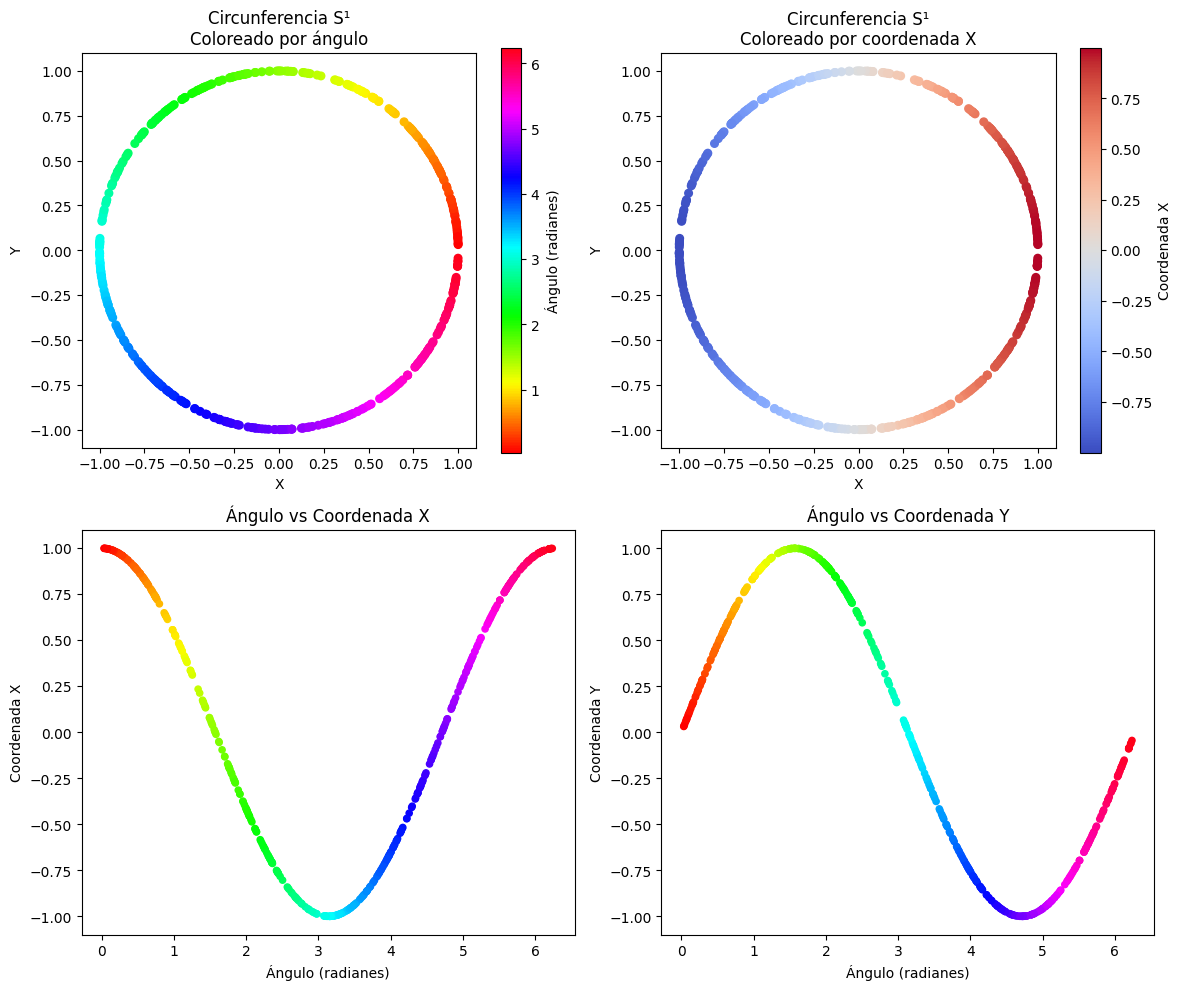

Datos S¹: 500 puntos
Radio promedio: 1.000000 (debe ser ≈1.0)
Desviación estándar del radio: 0.00000000
Rango de ángulos: [0.032, 6.239]


In [95]:
# Parte 4: S¹ - Perímetro del círculo unitario (circunferencia)
def generate_circle_boundary(n_samples=500, radius=1.0, random_state=42):
    """Genera puntos uniformemente distribuidos en la circunferencia"""
    np.random.seed(random_state)
    
    # Generar ángulos uniformemente distribuidos
    theta = np.random.uniform(0, 2*np.pi, n_samples)
    
    # Convertir a coordenadas cartesianas
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    
    return np.column_stack([x, y]), theta

# Generar datos de S¹
X_circle, theta_circle = generate_circle_boundary(n_samples=500, random_state=42)

# Visualizar los datos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Circunferencia coloreada por ángulo
im1 = axes[0,0].scatter(X_circle[:, 0], X_circle[:, 1], c=theta_circle, cmap='hsv', s=30)
axes[0,0].set_title('Circunferencia S¹\nColoreado por ángulo')
axes[0,0].set_xlabel('X')
axes[0,0].set_ylabel('Y')
axes[0,0].set_aspect('equal')
plt.colorbar(im1, ax=axes[0,0], label='Ángulo (radianes)')

# Circunferencia coloreada por coordenada x
im2 = axes[0,1].scatter(X_circle[:, 0], X_circle[:, 1], c=X_circle[:, 0], cmap='coolwarm', s=30)
axes[0,1].set_title('Circunferencia S¹\nColoreado por coordenada X')
axes[0,1].set_xlabel('X')
axes[0,1].set_ylabel('Y')
axes[0,1].set_aspect('equal')
plt.colorbar(im2, ax=axes[0,1], label='Coordenada X')

# Ángulo vs coordenada X
axes[1,0].scatter(theta_circle, X_circle[:, 0], c=theta_circle, cmap='hsv', s=20)
axes[1,0].set_xlabel('Ángulo (radianes)')
axes[1,0].set_ylabel('Coordenada X')
axes[1,0].set_title('Ángulo vs Coordenada X')

# Ángulo vs coordenada Y
axes[1,1].scatter(theta_circle, X_circle[:, 1], c=theta_circle, cmap='hsv', s=20)
axes[1,1].set_xlabel('Ángulo (radianes)')
axes[1,1].set_ylabel('Coordenada Y')
axes[1,1].set_title('Ángulo vs Coordenada Y')

plt.tight_layout()
plt.show()

# Verificar que todos los puntos están en la circunferencia
radii_circle = np.linalg.norm(X_circle, axis=1)
print(f"Datos S¹: {X_circle.shape[0]} puntos")
print(f"Radio promedio: {np.mean(radii_circle):.6f} (debe ser ≈1.0)")
print(f"Desviación estándar del radio: {np.std(radii_circle):.8f}")
print(f"Rango de ángulos: [{np.min(theta_circle):.3f}, {np.max(theta_circle):.3f}]")

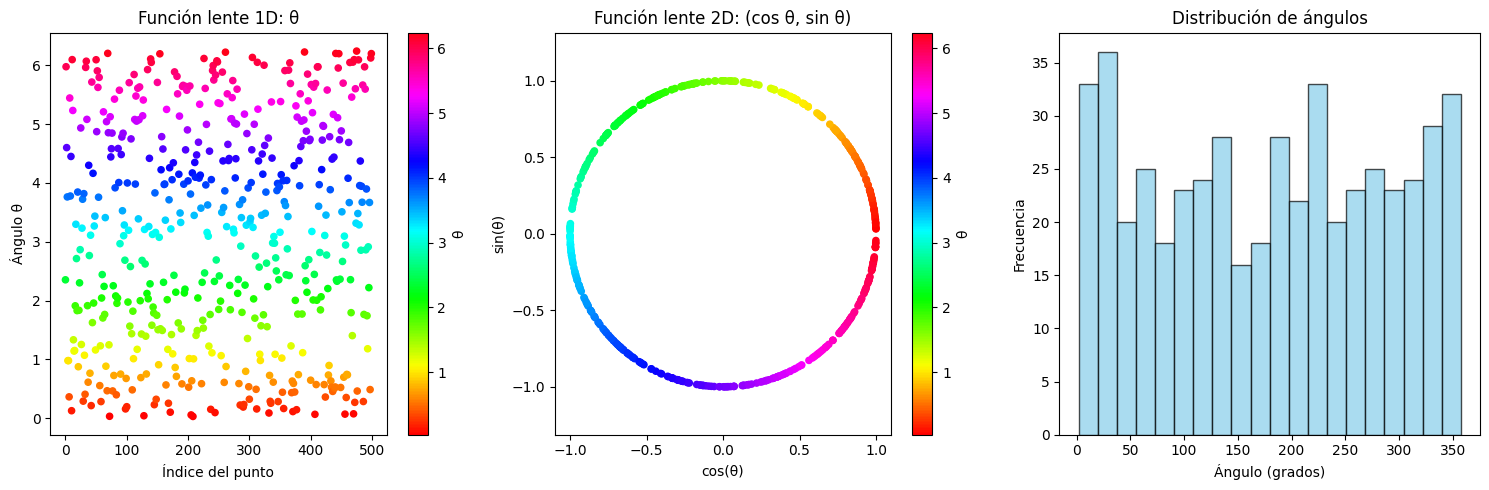

Grafo Mapper S¹ (1D): 9 nodos, 5 aristas
Grafo Mapper S¹ (2D): 27 nodos, 26 aristas


In [96]:
# Aplicar Mapper a S¹
# Para S¹, usaremos el ángulo θ como función lente (1D)
# También probamos con coordenadas (cos(θ), sin(θ)) como alternativa

# Opción 1: Usar solo el ángulo θ
y_circle_1d = theta_circle.reshape(-1, 1)

# Opción 2: Usar proyecciones trigonométricas para evitar discontinuidad en 2π
y_circle_2d = np.column_stack([np.cos(theta_circle), np.sin(theta_circle)])

# Configurar Mapper para S¹ (usando ángulo 1D)
cover_circle_1d = CubicalCover(n_intervals=12, overlap_frac=0.5)
clust_circle_1d = DBSCAN(eps=0.15, min_samples=2)
mapper_circle_1d = MapperAlgorithm(cover_circle_1d, clust_circle_1d)

# Construir grafo Mapper (1D)
graph_circle_1d = mapper_circle_1d.fit_transform(X_circle, y_circle_1d)

# Configurar Mapper para S¹ (usando proyecciones 2D)
cover_circle_2d = CubicalCover(n_intervals=10, overlap_frac=0.4)
clust_circle_2d = DBSCAN(eps=0.15, min_samples=3)
mapper_circle_2d = MapperAlgorithm(cover_circle_2d, clust_circle_2d)

# Construir grafo Mapper (2D)
graph_circle_2d = mapper_circle_2d.fit_transform(X_circle, y_circle_2d)

# Visualizar ambos grafos Mapper
fig_circle_1d = MapperPlot(graph_circle_1d, dim=2, seed=42, iterations=80).plot_plotly(
    colors=theta_circle
)
fig_circle_1d.update_layout(title="Mapper Graph - S¹ con función lente θ (1D) - Coloreado por ángulo")
fig_circle_1d.show(config={"scrollZoom": True})

fig_circle_2d = MapperPlot(graph_circle_2d, dim=2, seed=42, iterations=80).plot_plotly(
    colors=theta_circle
)
fig_circle_2d.update_layout(title="Mapper Graph - S¹ con función lente (cos θ, sin θ) (2D) - Coloreado por ángulo")
fig_circle_2d.show(config={"scrollZoom": True})

# Comparar los espacios de funciones lente
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(range(len(theta_circle)), theta_circle, c=theta_circle, cmap='hsv', s=20)
plt.xlabel('Índice del punto')
plt.ylabel('Ángulo θ')
plt.title('Función lente 1D: θ')
plt.colorbar(label='θ')

plt.subplot(1, 3, 2)
plt.scatter(y_circle_2d[:, 0], y_circle_2d[:, 1], c=theta_circle, cmap='hsv', s=20)
plt.xlabel('cos(θ)')
plt.ylabel('sin(θ)')
plt.title('Función lente 2D: (cos θ, sin θ)')
plt.colorbar(label='θ')
plt.axis('equal')

plt.subplot(1, 3, 3)
# Histograma circular de ángulos
angles_deg = np.degrees(theta_circle)
plt.hist(angles_deg, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Ángulo (grados)')
plt.ylabel('Frecuencia')
plt.title('Distribución de ángulos')

plt.tight_layout()
plt.show()

print(f"Grafo Mapper S¹ (1D): {graph_circle_1d.number_of_nodes()} nodos, {graph_circle_1d.number_of_edges()} aristas")
print(f"Grafo Mapper S¹ (2D): {graph_circle_2d.number_of_nodes()} nodos, {graph_circle_2d.number_of_edges()} aristas")

## Resumen y Análisis Comparativo

Comparamos los resultados obtenidos para cada conjunto de datos.

=== RESUMEN COMPARATIVO DE ANÁLISIS MAPPER ===
     Conjunto de Datos  Dimensión Original               Función Lente  Nodos Mapper  Aristas Mapper  Densidad Grafo
          B³ (Bola 3D)                   3                 PCA (3D→2D)            99              61          0.0126
S² (Superficie esfera)                   3 Coordenadas esféricas (θ,φ)           126             137          0.0174
      Círculo unitario                   2   Coordenadas polares (r,θ)           121             236          0.0325
               S¹ (1D)                   2               Ángulo θ (1D)             9               5          0.1389
               S¹ (2D)                   2 Proyecciones (cos θ, sin θ)            27              26          0.0741

=== ANÁLISIS TOPOLÓGICO ===

1. B³ (Bola 3D):
   - Estructura: Dominio contractible (topológicamente equivalente a un punto)
   - Mapper detecta la estructura radial desde el centro hacia la superficie
   - Varianza explicada por PCA: 0.351, 0.327

2

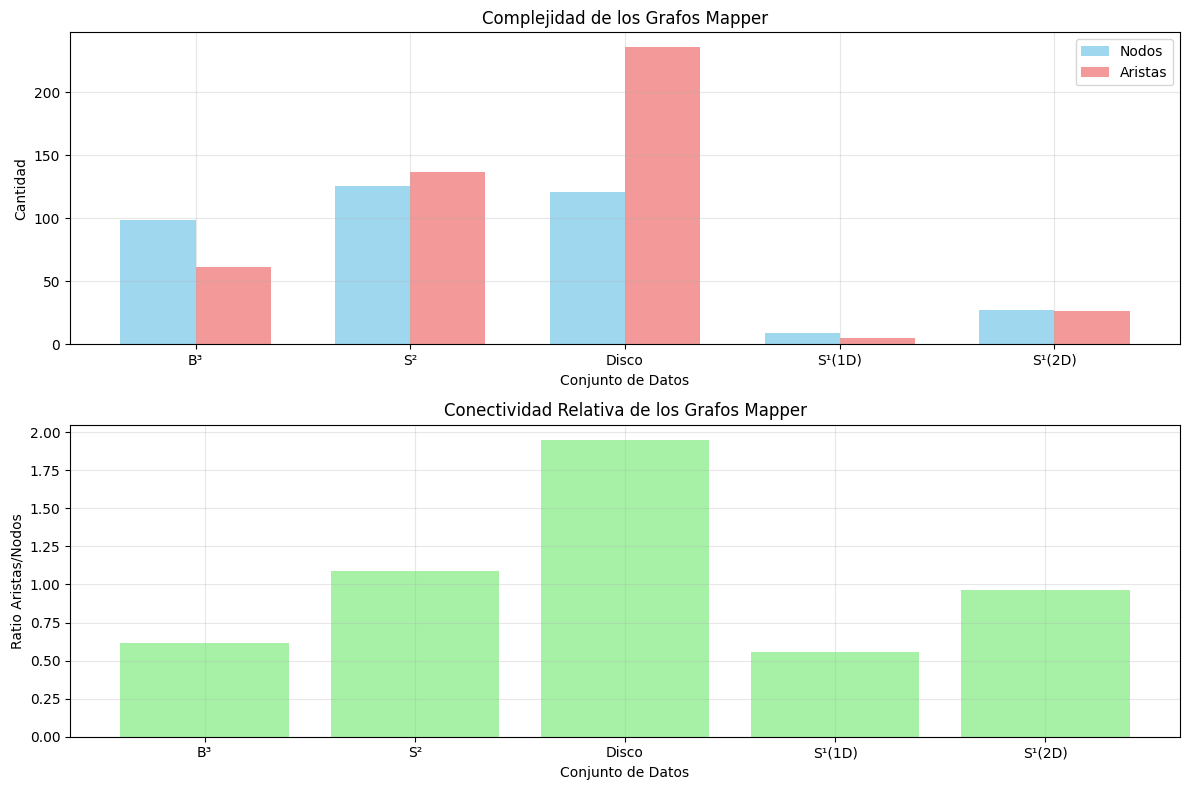


=== OBSERVACIONES FINALES ===
1. La elección de la función lente es crucial para capturar la estructura topológica
2. Estructuras más complejas (S²) requieren más nodos para representación adecuada
3. La dimensión de la función lente afecta la resolución del análisis
4. Mapper es efectivo para visualizar estructuras topológicas de diferentes dimensiones


In [97]:
# Resumen comparativo de todos los análisis
import pandas as pd

# Crear tabla resumen
results_summary = {
    'Conjunto de Datos': ['B³ (Bola 3D)', 'S² (Superficie esfera)', 'Círculo unitario', 'S¹ (1D)', 'S¹ (2D)'],
    'Dimensión Original': [3, 3, 2, 2, 2],
    'Función Lente': ['PCA (3D→2D)', 'Coordenadas esféricas (θ,φ)', 'Coordenadas polares (r,θ)', 'Ángulo θ (1D)', 'Proyecciones (cos θ, sin θ)'],
    'Nodos Mapper': [graph_ball3d.number_of_nodes(), graph_sphere.number_of_nodes(), 
                    graph_disk.number_of_nodes(), graph_circle_1d.number_of_nodes(), 
                    graph_circle_2d.number_of_nodes()],
    'Aristas Mapper': [graph_ball3d.number_of_edges(), graph_sphere.number_of_edges(), 
                      graph_disk.number_of_edges(), graph_circle_1d.number_of_edges(), 
                      graph_circle_2d.number_of_edges()],
    'Densidad Grafo': [2*graph_ball3d.number_of_edges()/(graph_ball3d.number_of_nodes()*(graph_ball3d.number_of_nodes()-1)) if graph_ball3d.number_of_nodes() > 1 else 0,
                      2*graph_sphere.number_of_edges()/(graph_sphere.number_of_nodes()*(graph_sphere.number_of_nodes()-1)) if graph_sphere.number_of_nodes() > 1 else 0,
                      2*graph_disk.number_of_edges()/(graph_disk.number_of_nodes()*(graph_disk.number_of_nodes()-1)) if graph_disk.number_of_nodes() > 1 else 0,
                      2*graph_circle_1d.number_of_edges()/(graph_circle_1d.number_of_nodes()*(graph_circle_1d.number_of_nodes()-1)) if graph_circle_1d.number_of_nodes() > 1 else 0,
                      2*graph_circle_2d.number_of_edges()/(graph_circle_2d.number_of_nodes()*(graph_circle_2d.number_of_nodes()-1)) if graph_circle_2d.number_of_nodes() > 1 else 0]
}

df_results = pd.DataFrame(results_summary)
print("=== RESUMEN COMPARATIVO DE ANÁLISIS MAPPER ===")
print(df_results.to_string(index=False, float_format='%.4f'))

# Análisis de las estructuras topológicas detectadas
print("\n=== ANÁLISIS TOPOLÓGICO ===")
print("\n1. B³ (Bola 3D):")
print("   - Estructura: Dominio contractible (topológicamente equivalente a un punto)")
print("   - Mapper detecta la estructura radial desde el centro hacia la superficie")
print(f"   - Varianza explicada por PCA: {pca_ball3d.explained_variance_ratio_[0]:.3f}, {pca_ball3d.explained_variance_ratio_[1]:.3f}")

print("\n2. S² (Superficie de esfera):")
print("   - Estructura: Variedad cerrada de dimensión 2, no contractible")
print("   - Mapper revela la estructura esférica a través de coordenadas esféricas")
print("   - Permite visualizar cómo se 'desenrolla' la superficie esférica")

print("\n3. Círculo unitario (disco):")
print("   - Estructura: Dominio contractible con borde circular")
print("   - Mapper captura tanto la estructura radial como la angular, la estructura en 1D son varios subgrafos con 1-3 nodos conectados y la polar  (2D) es una cadena")

print("\n4. S¹ (Circunferencia):")
print("   - Estructura: Ciclo fundamental, primera característica topológica no trivial")
print("   - Comparación entre función lente 1D vs 2D:")
print(f"     * 1D (θ): {graph_circle_1d.number_of_nodes()} nodos, puede tener discontinuidad en 2π")
print(f"     * 2D (cos θ, sin θ): {graph_circle_2d.number_of_nodes()} nodos, preserva continuidad circular")

# Visualización comparativa de complejidad
plt.figure(figsize=(12, 8))

datasets = ['B³', 'S²', 'Disco', 'S¹(1D)', 'S¹(2D)']
nodes = [graph_ball3d.number_of_nodes(), graph_sphere.number_of_nodes(), 
         graph_disk.number_of_nodes(), graph_circle_1d.number_of_nodes(), 
         graph_circle_2d.number_of_nodes()]
edges = [graph_ball3d.number_of_edges(), graph_sphere.number_of_edges(), 
         graph_disk.number_of_edges(), graph_circle_1d.number_of_edges(), 
         graph_circle_2d.number_of_edges()]

x = np.arange(len(datasets))
width = 0.35

plt.subplot(2, 1, 1)
plt.bar(x - width/2, nodes, width, label='Nodos', alpha=0.8, color='skyblue')
plt.bar(x + width/2, edges, width, label='Aristas', alpha=0.8, color='lightcoral')
plt.xlabel('Conjunto de Datos')
plt.ylabel('Cantidad')
plt.title('Complejidad de los Grafos Mapper')
plt.xticks(x, datasets)
plt.legend()
plt.grid(True, alpha=0.3)

# Ratio aristas/nodos
ratios = [e/n if n > 0 else 0 for e, n in zip(edges, nodes)]
plt.subplot(2, 1, 2)
plt.bar(datasets, ratios, alpha=0.8, color='lightgreen')
plt.xlabel('Conjunto de Datos')
plt.ylabel('Ratio Aristas/Nodos')
plt.title('Conectividad Relativa de los Grafos Mapper')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== OBSERVACIONES FINALES ===")
print("1. La elección de la función lente es crucial para capturar la estructura topológica")
print("2. Estructuras más complejas (S²) requieren más nodos para representación adecuada")
print("3. La dimensión de la función lente afecta la resolución del análisis")
print("4. Mapper es efectivo para visualizar estructuras topológicas de diferentes dimensiones")

## Anexo: Probando MAPPER con un conjunto de datos para un proyecto: datos de salud de estudiantes y trabajadores de la UNAM.

Se usa el interfaz Streamlit de mapper (https://github.com/lucasimi/tda-mapper-python) para subir el CSV y explorar los datos. Los datos vienen del "Proyecto 42" de C3 en la UNAM. Fuente: https://chilam.c3.unam.mx/proyectos/proyecto-42. El interfaz se usa para experimentar con diferentes parametros y ajustes. En el ejemplo abajo, se usa una lente de PCA (2 dimensiones), clustering de KMEans y un cover de cubos (cubical).


En general, se ve que MAPPER identifica dos subconjuntos, uno con alta relevancia y otro con baja relevancia para predecir obesidad.

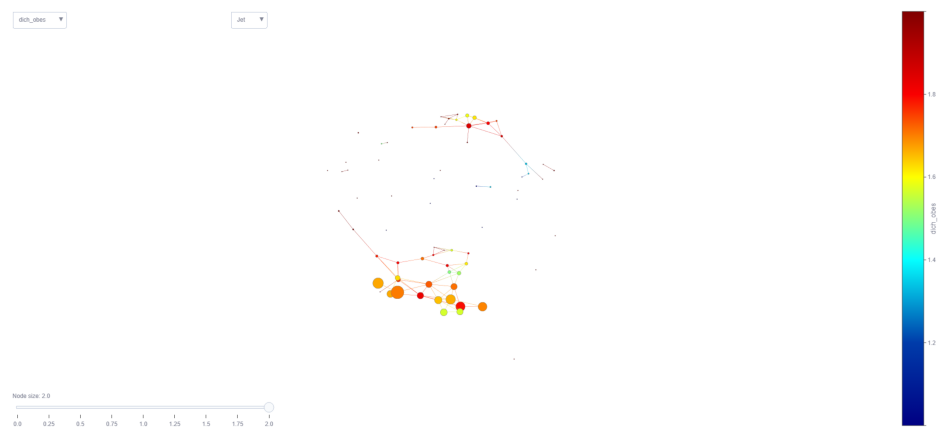

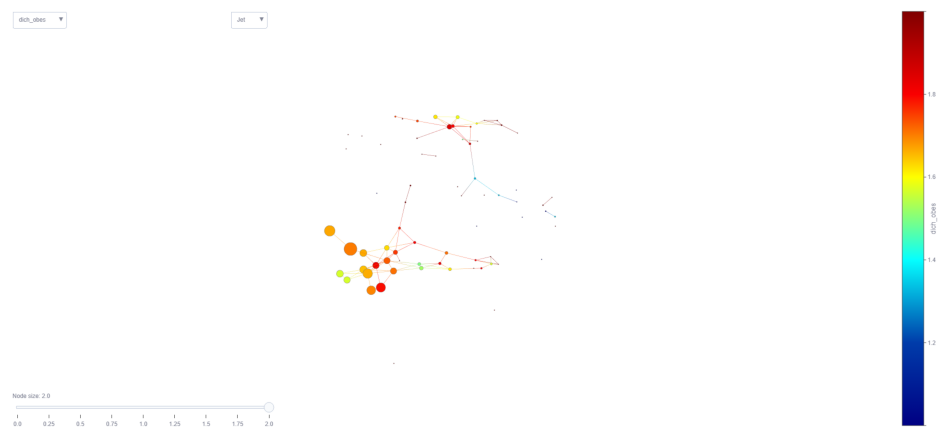

In [99]:
def load_image_from_downloads(filename):
    downloads_path = r"B:\thano\Downloads"
    image_path = os.path.join(downloads_path, filename)
    
    if os.path.exists(image_path):
            img = Image.open(image_path)
            plt.figure(figsize=(12, 8))
            plt.imshow(img)
            plt.axis('off')

# Ejemplo de uso de la función para cargar una imagen específica
load_image_from_downloads("newplot.png")
load_image_from_downloads("newplot (1).png")
